# All-in-One Category Processing

Combines all important steps done in notebooks 40-41 (but without extra analytics).

1. Get subset of products with categories
2. Update categories to fix taxonomy issues (e.g. adapt latest updates and include full parent hierarchy)
3. Compute and aggregate Nutri-Score information per category
4. Build category hierarchy for known categories
5. Prune related categories that are similar in terms of Nutri-Score characteristics (no added value for category differentiation)

In [1]:
from openfoodfacts.taxonomy import get_taxonomy, Taxonomy
import networkx as nx
import pandas as pd

## Load Category Taxonomy

In [2]:
categories: Taxonomy = get_taxonomy("category", download_newer=True)
print(f"{len(categories):,} categories")

/Users/goerlitz/.cache/openfoodfacts/taxonomy/category.json: 100%|██████████| 6.39M/6.39M [00:00<00:00, 12.5MB/s]


14,180 categories


## Load Dataset

In [3]:
file_path = "../data/off_scans_dd.csv.gz"
df = pd.read_csv(file_path, dtype={'code':str})
df = df[df.code.notna()].set_index('code') # exclude empty barcodes

# split comma separated lists
for col in ['categories_tags', 'countries_tags']:
    df[col] = df[col].str.split(',')

# use Int64 for counts with NaN
for col in ['scans_n', 'unique_scans_n']:
    df[col] = df[col].astype('Int64')

display(df)

,product_name,categories_tags,countries_tags,nutriscore_grade,scans_n,unique_scans_n
code,,,,,,
0000101209159,Véritable pâte à tartiner noisettes chocolat noir,"[en:breakfasts, en:spreads, en:sweet-spreads, ...",[en:france],e,1,1
0000105000011,Chamomile Herbal Tea,[en:null],[en:united-states],unknown,2,1
0000105000042,"Lagg's, herbal tea, peppermint","[en:plant-based-foods-and-beverages, en:bevera...",[en:united-states],unknown,<NA>,<NA>
0000105000059,Linden Flowers Tea,"[en:beverages-and-beverages-preparations, en:p...",[en:united-states],unknown,<NA>,<NA>
0000105000073,"Herbal Tea, Hibiscus",NaN,[en:united-states],unknown,<NA>,<NA>
...,...,...,...,...,...,...
55940115,NaN,NaN,[en:france],NaN,<NA>,<NA>
8797790833636,NaN,"[en:plant-based-foods-and-beverages, en:plant-...",[en:france],a,<NA>,<NA>
0170111061716,Salted Caramel protein bar,NaN,[en:netherlands],unknown,<NA>,<NA>


### Select Products with categories

- 1.65 million products have categories

In [4]:
df_cats = df.dropna(subset=['categories_tags']).copy()
df_cats

,product_name,categories_tags,countries_tags,nutriscore_grade,scans_n,unique_scans_n
code,,,,,,
0000101209159,Véritable pâte à tartiner noisettes chocolat noir,"[en:breakfasts, en:spreads, en:sweet-spreads, ...",[en:france],e,1,1
0000105000011,Chamomile Herbal Tea,[en:null],[en:united-states],unknown,2,1
0000105000042,"Lagg's, herbal tea, peppermint","[en:plant-based-foods-and-beverages, en:bevera...",[en:united-states],unknown,<NA>,<NA>
0000105000059,Linden Flowers Tea,"[en:beverages-and-beverages-preparations, en:p...",[en:united-states],unknown,<NA>,<NA>
0000105000196,Apple & Cinnamon Tea,[en:null],[en:united-states],unknown,<NA>,<NA>
...,...,...,...,...,...,...
0617201892435,Mixel Lentil Dal,"[en:plant-based-foods-and-beverages, en:plant-...",[en:united-states],a,<NA>,<NA>
5063089223994,NaN,"[en:beverages-and-beverages-preparations, en:b...",[en:united-kingdom],c,<NA>,<NA>
4820220134103,Морозиво пломбір &quot;Хрещатик Київський&quot...,"[en:desserts, en:frozen-foods, en:frozen-desse...",[en:ukraine],e,<NA>,<NA>


## Process Categories

Fix category taxonomy issues, like renamed categories, remodeled hierarchy, missing parent categories

In [5]:
replace = {
  # not a real category
  'en:groceries': None,
  'en:undefined': None,
  'en:null': None,
  'en:toppings-ingredients': None,
  # adjust renamed categories
  'en:salads': 'en:prepared-salads',
  'en:salted-snacks': 'en:salty-snacks',
  'en:dairy-spread': 'en:dairy-spreads',
  'en:squeezed-juices': 'en:squeezed-fruit-juices',
  'en:bars-covered-with-chocolate': 'en:candy-chocolate-bars',
  'en:drinkable-yogurts': 'en:yogurt-drinks',
  'en:raw-cured-ham': 'en:dried-hams',
  # revert remodeled hierarchy
  'en:pickled-gherkins': 'en:gherkins',
  'en:milks-liquid-and-powder': 'en:milks',
}

# Apply replacements to categories
df_cats['categories'] = df_cats['categories_tags'].apply(
    lambda cats: [replace.get(cat, cat) for cat in cats]
)

In [6]:
def with_all_parents(names: list) -> set:
    """Get the hierarchy of categories for a list of category names."""
    cats = [categories[name] for name in names if name in categories]
    nodes = [node for c in cats for node in c.get_parents_hierarchy()]
    return [node.id for node in set([*cats, *nodes])]

# apply taxonomy by adding parent categories
df_cats['all_categories'] = df_cats['categories'].apply(with_all_parents)

### Check Tag Difference after Update

In [7]:
# compute difference between categories and categories_tags
df_cats['diff'] = df_cats.apply(lambda row: [c for c in row.all_categories if c not in row.categories_tags], axis=1)
df_cats['diff'].explode().dropna().value_counts().head(25)

diff
en:beverages-and-beverages-preparations      128718
en:vegetable-based-foods-and-beverages        55670
en:biscuits-and-crackers                      36987
en:beverage-preparations                      17002
en:herbs-and-spices                           12973
en:milks-liquid-and-powder                    12013
en:snacks                                      6567
en:salty-snacks                                6283
en:pasteurised-products                        4541
en:festive-foods                               4537
en:vegan-products                              3612
en:potatoes-and-their-products                 3612
en:squeezed-fruit-juices                       2890
en:pound-cake                                  2552
en:combination-meals                           2193
en:prepared-salads                             2102
en:vegetables                                  2054
en:fromages-blancs-petit-suisses-and-skyr      2030
en:meals                                       1953
en:inco

### Additional Checks

- non-food products

In [8]:
non_food = df_cats.all_categories.apply(lambda x: 'en:non-food-products' in x)
df_cats.loc[non_food]

,product_name,categories_tags,countries_tags,nutriscore_grade,scans_n,unique_scans_n,categories,all_categories,diff
code,,,,,,,,,
0072058610579,Nectar Consistency Thickened Water,"[en:non-food-products, en:open-products-facts]",[en:united-states],not-applicable,<NA>,<NA>,"[en:non-food-products, en:open-products-facts]","[en:open-products-facts, en:non-food-products,...",[en:incorrect-product-type]
0085239015414,White coffee filters,[en:non-food-products],[en:united-states],not-applicable,<NA>,<NA>,[en:non-food-products],"[en:incorrect-product-type, en:non-food-products]",[en:incorrect-product-type]
0210014490494,Schafmilchseife,[en:non-food-products],[en:switzerland],not-applicable,<NA>,<NA>,[en:non-food-products],"[en:incorrect-product-type, en:non-food-products]",[en:incorrect-product-type]
0885967206272,dishwashing liquid,"[en:non-food-products, en:open-products-facts,...",[en:canada],not-applicable,1,1,"[en:non-food-products, en:open-products-facts,...","[en:open-products-facts, en:non-food-products,...",[en:incorrect-product-type]
20796723,NaN,[en:non-food-products],[en:switzerland],not-applicable,1,1,[en:non-food-products],"[en:incorrect-product-type, en:non-food-products]",[en:incorrect-product-type]
...,...,...,...,...,...,...,...,...,...
86017886,lucky strike,"[en:cigarettes, en:non-food-products]",[en:serbia],not-applicable,1,1,"[en:cigarettes, en:non-food-products]","[en:incorrect-product-type, en:open-products-f...","[en:incorrect-product-type, en:open-products-f..."
3245678159965,Gel anti-calcaire,"[en:non-food-products, en:open-products-facts]","[en:france, en:world]",not-applicable,1,1,"[en:non-food-products, en:open-products-facts]","[en:open-products-facts, en:non-food-products,...",[en:incorrect-product-type]
0037000907855,Crest Complete Plus Scope,"[en:non-food-products, en:open-beauty-facts]",[en:united-states],NaN,1,1,"[en:non-food-products, en:open-beauty-facts]","[en:incorrect-product-type, en:non-food-produc...",[en:incorrect-product-type]


---

## Process Nutri-Score

- Count products per category and Nutri-Score grade
- Add label that reflects the dominant Nutri-Score grades

In [9]:
cols = ['all_categories', 'nutriscore_grade']
min_scans = 10
min_total = 300
max_grades = 4


cnt = df_cats.loc[lambda x: x.unique_scans_n >= min_scans].shape[0]
print(f"{cnt:,} categories with at least {min_scans} scans")

def grade_label(row, grades = ['a', 'b', 'c', 'd', 'e'], min_ratio = 0.10):
    """Determine the Nutri-Score label for a category based on grade counts."""
    if row['not-applicable'] / row.total > 0.5:
        return "not-applicable"
    
    total = row[grades].sum()
    if total == 0:
        return None
    counts = {k:row[k] for k in grades}
    non_zero = [k for k,v in counts.items() if v/total >= min_ratio]
    return ','.join(non_zero)

# group by (exploded) categories and sum up by Nutri-Score grades
grade_counts = (
  df_cats.loc[lambda x: x.unique_scans_n >= min_scans, cols]
  .dropna(subset=cols) 
  .explode(cols[0])
  .dropna(subset=cols)
  .groupby(cols, dropna=False).size() # count grades per category
  .unstack(fill_value=0)
  .astype(int)
  .assign(total=lambda x: x.sum(axis=1))
  .assign(label=lambda x: x.apply(grade_label, axis=1))
  # .assign(scans=lambda x: x.unique_scans_n.sum())
  .sort_values('total', ascending=False)
  .loc[lambda x: x.index.str.startswith('en:') & (x.total >= min_total)]
)
grade_counts

59,942 categories with at least 10 scans


nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,label
all_categories,,,,,,,,,
en:plant-based-foods-and-beverages,5093,4036,6419,4091,1543,392,2613,24187,"a,b,c,d"
en:plant-based-foods,5003,3624,5518,3690,1118,383,2144,21480,"a,b,c,d"
en:snacks,238,272,1551,3477,5834,493,714,12579,"c,d,e"
en:cereals-and-potatoes,2089,1459,3017,2039,442,29,778,9853,"a,b,c,d"
en:sweet-snacks,81,133,689,2002,5293,464,541,9203,"d,e"
...,...,...,...,...,...,...,...,...,...
en:white-hams,8,12,181,99,1,0,9,310,"c,d"
en:ice-creams,1,6,40,134,111,1,14,307,"c,d,e"
en:extra-virgin-olive-oils,0,271,0,0,0,0,34,305,b


In [10]:
grade_counts.label.str.split(',').apply(len).value_counts().sort_index()

label
1    21
2    56
3    93
4    48
5     8
Name: count, dtype: int64

In [11]:
grade_counts.label.value_counts()

label
a,b,c             42
c,d,e             31
a,b,c,d           28
d,e               21
c,d               19
b,c,d,e           13
b,c                9
a,c,d              9
a,b,c,d,e          8
b,c,d              6
e                  6
a,c,d,e            5
a                  5
not-applicable     5
b                  4
a,b                3
a,b,c,e            2
a,b,d              2
a,c                2
a,d,e              1
b,d,e              1
b,d                1
b,c,e              1
c,e                1
d                  1
Name: count, dtype: int64

---

## Build Category Graph

parent fr:pates-a-tartiner of en:chocolate-spreads is not in English
parent fr:pates-a-tartiner of en:hazelnut-spreads is not in English
#Nodes: 217
#Edges: 256
prunable nodes: 73


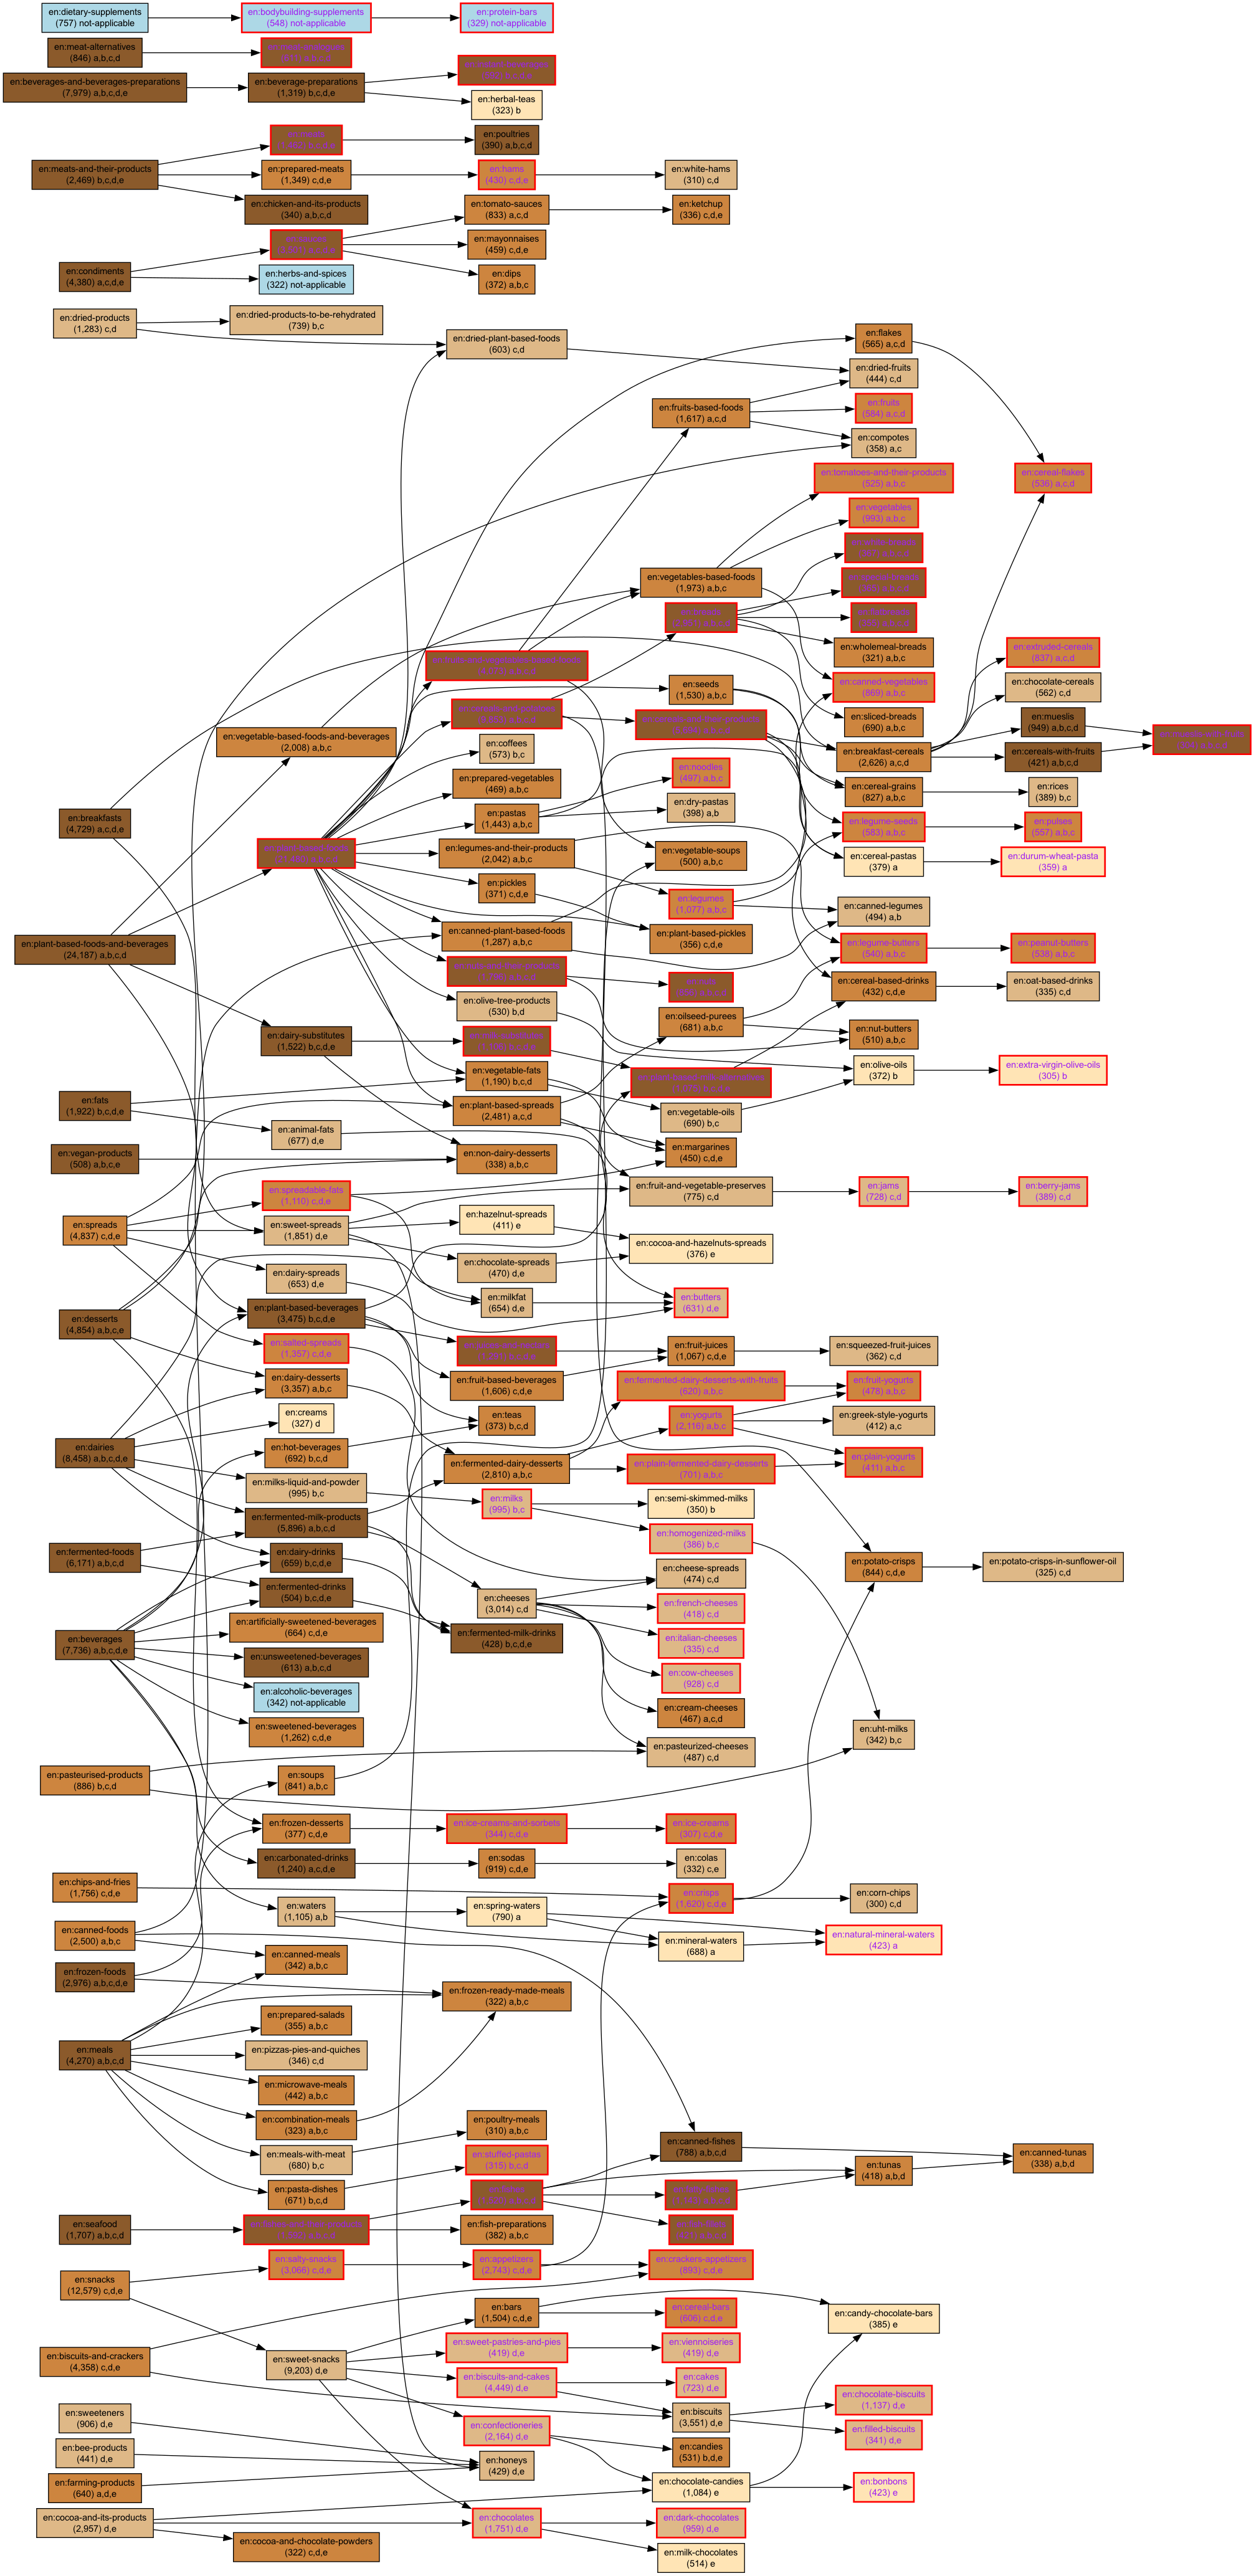

In [12]:
import pydot
from networkx.drawing.nx_pydot import to_pydot
from IPython.display import Image

def create_graph(df: pd.DataFrame, max_grades=4) -> nx.DiGraph:
  """Create a directed graph from a list of taxonomy nodes."""
  G = nx.DiGraph();
  
  names = df.loc[lambda x: x.label.str.split(',').apply(len) <= max_grades].index

  for cat in names:

    node = categories[cat]
    if not node:
      print(f"category {cat} ({df.loc[cat].all_count}) not found in taxonomy")
      continue

    for parent in node.parents:
      if not parent.id.startswith('en:'):
        print(f"parent {parent.id} of {cat} is not in English")
        continue

      if not parent.id in df.index:
        print(f"parent {parent.id} of '{cat}' ({df.loc[cat].all_count}) not found in df")

      G.add_edge(parent.id.replace(':', '.'), node.id.replace(':', '.'))
  return G

def find_prunable_nodes(G: nx.DiGraph, df: pd.DataFrame) -> list:
  """Find nodes that can be pruned from the graph."""
  prunable = []
  for node_id in G.nodes:
    # ignore root nodes (no incoming edges)
    if G.in_degree(node_id) == 0:
      continue
    name = node_id.replace('.', ':')
    cat = categories[name]
    if cat is not None and all(p.id in df.index and df.loc[p.id].label == df.loc[name].label for p in cat.parents):
      prunable.append(name)
  return prunable

def add_labels(G, grade_counts: pd.DataFrame):
  """Add labels to the graph nodes based on category details."""
  for node_id in G.nodes:
    name = node_id.replace('.', ':')

    if not name in grade_counts.index:
      print(f"node '{name}' not found in df")
      continue
    cat = grade_counts.loc[name]
    G.nodes[node_id]['label'] = f"{name}\n({cat.total:,}) {cat.label}"

def plot_graph(G: nx.DiGraph, df: pd.DataFrame, prunable=[], node_sep=0.1, rank_sep=0.5):
  """Plot the graph using PyDot with specific layout settings."""
  P = to_pydot(G)

  # Identify root nodes (no incoming edges)
  roots = [n for n in G.nodes if G.in_degree(n) == 0]

  # Create a subgraph for same-rank roots
  same_rank_subgraph = pydot.Subgraph(rank='same')
  for root in roots:
      node = P.get_node(root)[0]
      same_rank_subgraph.add_node(node)

  # Inject the subgraph into the pydot graph
  P.add_subgraph(same_rank_subgraph)

  P.set('rankdir', 'LR') # left to right
  P.set('nodesep', node_sep)
  P.set('ranksep', rank_sep)

  for node in P.get_nodes():
      
      # gives nodes a color based on the range of Nutri-Scores (via label length)
      name = node.get_name().strip('"').replace('.', ':')

      # print(f"node: {name} {name in df.index}")

      if name in df.index:
        label_len = len(df.loc[name].label)
        color = {1: "moccasin", 3: "burlywood", 5: "tan3", 14: "lightblue"}.get(label_len, "tan4")
      else:
        color = 'grey'

      node.set_fontname('Arial')
      node.set_shape('box')
      node.set_height(0) # remove top/bottom padding
      node.set_fontsize(11)
      node.set_style("filled")
      node.set_fillcolor(color)
      
      # give the node a red border if all parents have the same Nutri-Score labels
      if name in prunable:
        node.set_color('red')
        node.set_fontcolor('purple')
        node.set_penwidth(2)

  return P

G = create_graph(grade_counts, max_grades=max_grades)

print(f"#Nodes: {len(G.nodes):,}")
print(f"#Edges: {len(G.edges):,}")

add_labels(G, grade_counts)
prunable = find_prunable_nodes(G, grade_counts)
print(f"prunable nodes: {len(prunable):,}")

P = plot_graph(G, grade_counts, prunable)
Image(P.create_png())

## Removed marked categories

In [13]:
def prune_graph(G: nx.DiGraph, nodes: list):
    """Prune the graph by removing predefined nodes."""
    for node in nodes:
        name = node.replace(':', '.')
        parents = list(G.predecessors(name))
        children = list(G.successors(name))
        
        for p in parents:
            for c in children:
                G.add_edge(p, c)
        G.remove_node(name)

prune_graph(G, prunable)
print(f"#Nodes after pruning: {len(G.nodes):,}")
print(f"#Edges after pruning: {len(G.edges):,}")

#Nodes after pruning: 144
#Edges after pruning: 172


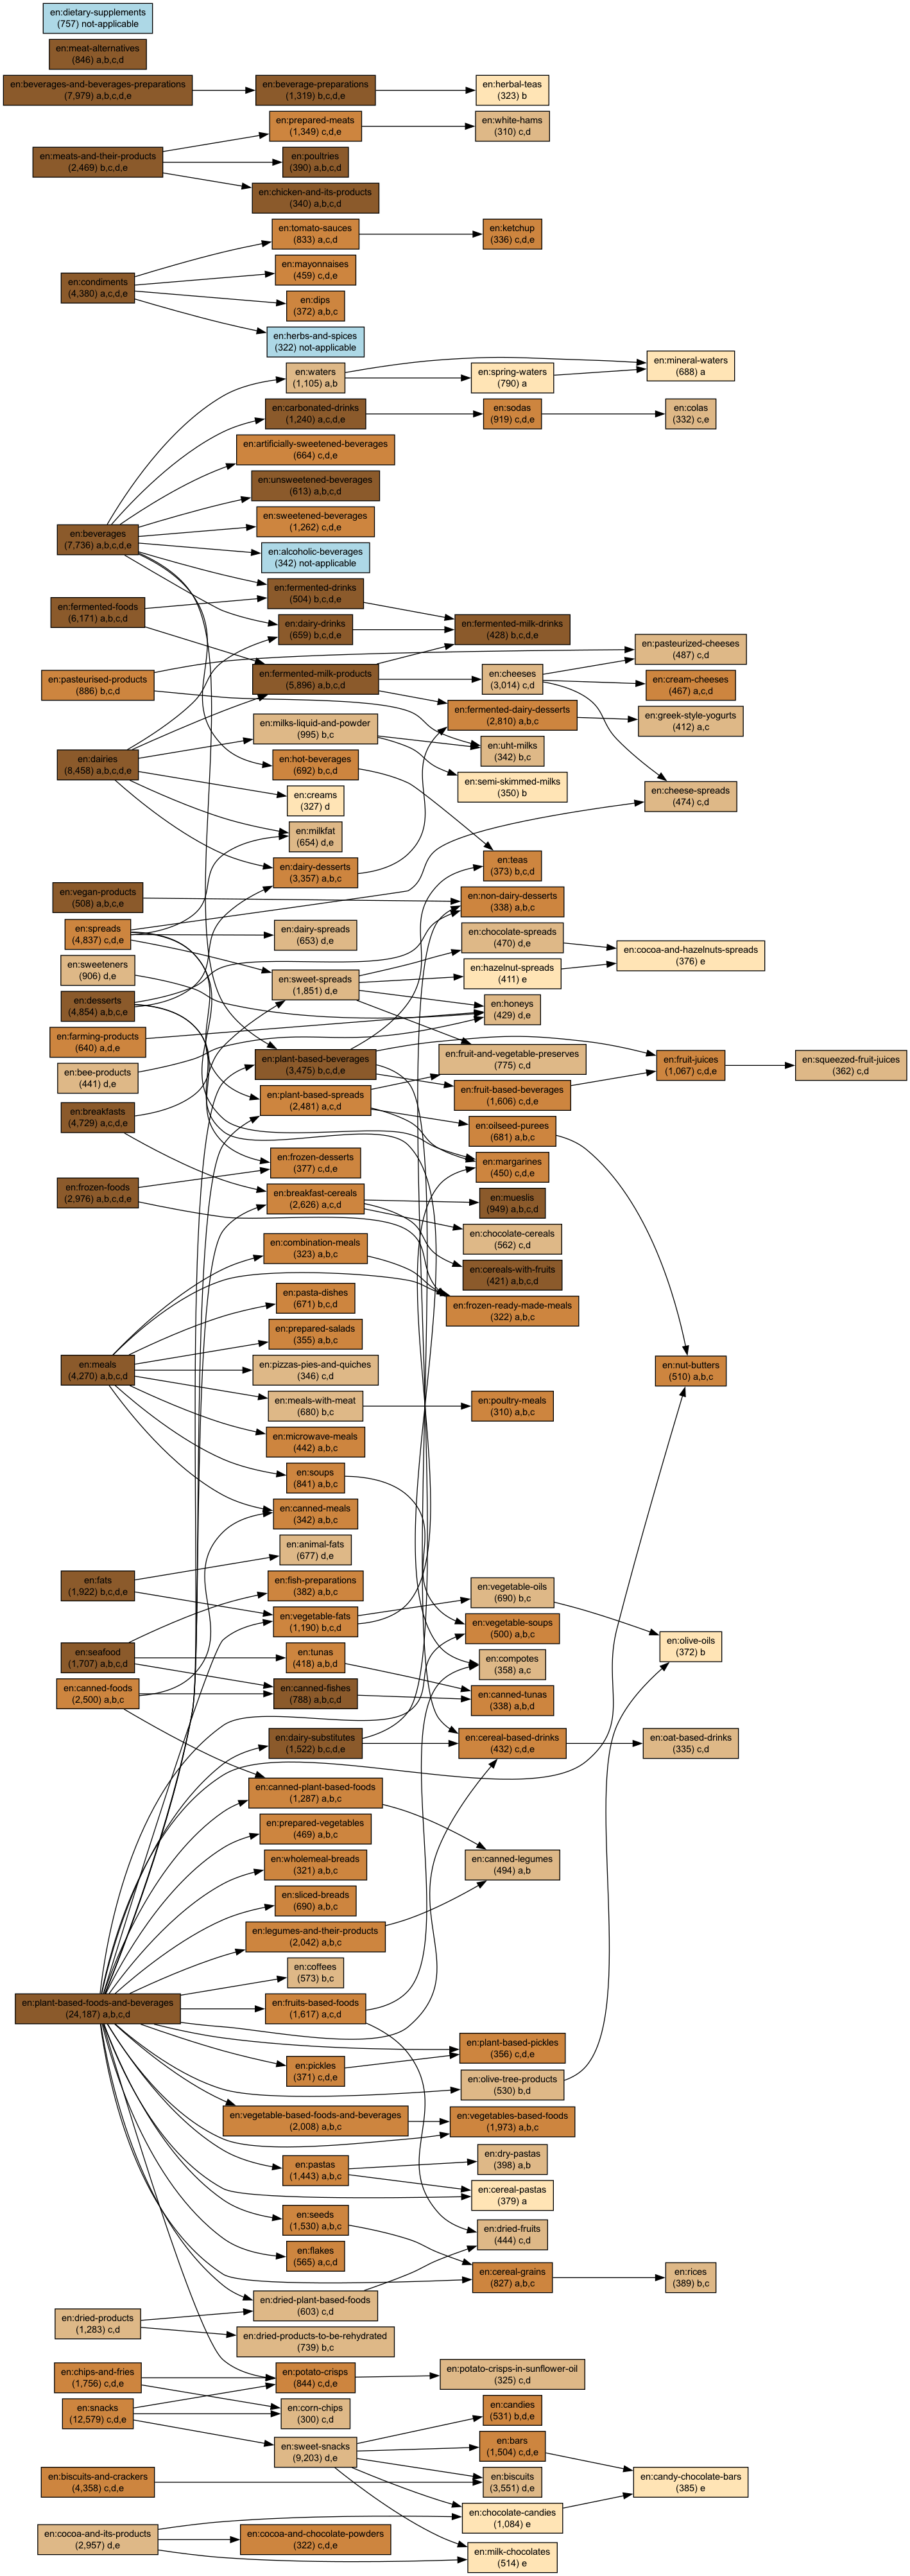

In [14]:
P = plot_graph(G, grade_counts, prunable)
Image(P.create_png())

## Extract remaining nodes

In [15]:
selection = (
    grade_counts.loc[lambda x: x.index.intersection([n.replace('.', ':') for n in G.nodes])]
                .loc[lambda x: x.label.str.split(',').apply(len) <= max_grades]
                .sort_values('total', ascending=False)
)
selection

nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,label
all_categories,,,,,,,,,
en:plant-based-foods-and-beverages,5093,4036,6419,4091,1543,392,2613,24187,"a,b,c,d"
en:snacks,238,272,1551,3477,5834,493,714,12579,"c,d,e"
en:sweet-snacks,81,133,689,2002,5293,464,541,9203,"d,e"
en:fermented-foods,922,729,1759,1883,394,15,469,6171,"a,b,c,d"
en:fermented-milk-products,859,674,1621,1882,390,14,456,5896,"a,b,c,d"
...,...,...,...,...,...,...,...,...,...
en:herbs-and-spices,12,3,5,1,10,281,10,322,not-applicable
en:wholemeal-breads,137,104,58,5,2,0,15,321,"a,b,c"
en:poultry-meals,31,92,161,15,4,0,7,310,"a,b,c"


In [16]:
# 50/[150|200|300]/#4
# 1  33 26 15
# 2  61 48 39
# 3  91 78 61
# 4  34 32 25

selection.label.str.split(',').apply(len).value_counts().sort_index()

label
1    15
2    39
3    61
4    25
Name: count, dtype: int64

In [17]:
selection.label.value_counts()

label
a,b,c             26
c,d,e             20
c,d               14
a,b,c,d           12
d,e               11
b,c,d,e            8
b,c                7
a,c,d              6
b,c,d              5
e                  5
a,b                3
a,c,d,e            3
a                  3
not-applicable     3
b                  3
a,b,c,e            2
a,b,d              2
a,c                2
a,d,e              1
b,d,e              1
b,d                1
c,e                1
d                  1
Name: count, dtype: int64

## Check Coverage

scans/freq:
- 20/100/#3 = 138 cats -> 67% of 1.65m, 85% of 60k
- 10/100/#3 = 246 cats -> 75% of 1.65m, 88% of 60k
- 10/150/#3 = 184 cats -> 74% of 1.65m, 87% of 60k
- 10/200/#3 = 151 cats -> 72% of 1.65m, 85% of 60k
- 10/300/#3 = 115 cats -> 69.5% of 1.65m, 81.7% of 60k
-  5/200/#3 = 257 cats -> 75% of 1.65m, 86% of 60k
- 10/100/#4 = 285 cats -> 88% of 1.65m, 96% of 60k
- 10/150/#4 = 219 cats -> 88.5% of 1.65m, 96.3% of 60k
- 10/200/#4 = 184 cats -> 88% of 1.65m, 96% of 60k
- 10/250/#4 = 158 cats -> 88% of 1.65m, 96% of 60k
- 10/300/#4 = 140 cats -> 88% of 1.65m, 96% of 60k ***

In [18]:
df_cats.loc[lambda df: df.all_categories.apply(lambda x: any(c in selection.index for c in x))].shape[0] / len(df_cats.index)

0.8799286541714529

In [19]:
scans = df_cats.loc[lambda x: x.unique_scans_n >= min_scans]
scans.loc[lambda df: df.all_categories.apply(lambda x: any(c in selection.index for c in x))].shape[0] / len(scans.index)

0.9594441293250142

In [20]:
rest = scans.loc[lambda df: ~df.all_categories.apply(lambda x: any(c in selection.index for c in x))]
rest

,product_name,categories_tags,countries_tags,nutriscore_grade,scans_n,unique_scans_n,categories,all_categories,diff
code,,,,,,,,,
0009800007615,Tic Tac Freshmints,[en:null],[en:united-states],a,11,11,[None],[],[]
0009800892204,Hazelnut Spread With Cocoa,[en:null],[en:united-states],e,18,12,[None],[],[]
00001977,Sliced Cracked Wheat Sourdough Bread,[en:sourdough-bread],[en:united-states],c,24,17,[en:sourdough-bread],[],[]
00015356,Salsa Autentica,[en:null],[en:united-states],c,11,10,[None],[],[]
00018166,Ultimate Crumpets,[en:crumpets],"[en:france, en:united-kingdom]",c,53,49,[en:crumpets],[],[]
...,...,...,...,...,...,...,...,...,...
4006381492263,Surligneur &quot;Boss Original&quot; Vert Past...,"[en:highlighters, en:office-equipment-and-acce...","[en:australia, en:france]",c,11,11,"[en:highlighters, en:office-equipment-and-acce...",[],[]
3596710483754,Mouchoirs 2 épaisseurs,"[en:non-food-products, en:open-beauty-facts]","[en:france, en:world]",not-applicable,11,11,"[en:non-food-products, en:open-beauty-facts]","[en:incorrect-product-type, en:non-food-produc...",[en:incorrect-product-type]
5998749117798,Friandises au fromage pour chats,"[en:dog-and-cat-food, en:cat-food]",[en:france],a,12,10,"[en:dog-and-cat-food, en:cat-food]",[],[]


In [21]:
rest_count = rest.all_categories.explode().value_counts().loc[lambda x: x>= 50]#.head(25)

rest_grades = grade_counts.loc[[c for c in rest_count.index if c in grade_counts.index]].sort_values('total', ascending=False)
rest_grades

nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,label
all_categories,,,,,,,,,
en:dairies,957,1264,2194,2270,1040,63,670,8458,"a,b,c,d,e"
en:beverages-and-beverages-preparations,768,1181,1898,952,1223,418,1539,7979,"a,b,c,d,e"
en:beverages,768,1143,1883,946,1216,417,1363,7736,"a,b,c,d,e"
en:frozen-foods,570,440,796,615,432,38,85,2976,"a,b,c,d,e"
en:broths,9,22,117,4,31,5,157,345,"b,c,e"


---

In [22]:
# match with scans

cols = ['all_categories', 'unique_scans_n']
cat_scans = df_cats[cols].dropna(subset=cols).explode(cols[0]).groupby(cols[0], dropna=False).sum().sort_values(cols[1], ascending=False)

selection['scans'] = selection.index.map(cat_scans['unique_scans_n'])
selection['parents'] = selection.index.map(lambda x: ', '.join([p.id for p in categories[x].parents]))

In [23]:
selection.loc[lambda x: x.label.str.split(',').apply(len) <= 2].sort_values(['scans'], ascending=False)

nutriscore_grade,a,b,c,d,e,not-applicable,unknown,total,label,scans,parents
all_categories,,,,,,,,,,,
en:sweet-snacks,81,133,689,2002,5293,464,541,9203,"d,e",497373,en:snacks
en:biscuits,42,46,316,810,2136,25,176,3551,"d,e",177687,"en:biscuits-and-cakes, en:biscuits-and-crackers"
en:cheeses,203,129,530,1658,256,1,237,3014,"c,d",165405,en:fermented-milk-products
en:cocoa-and-its-products,5,5,27,326,2153,30,411,2957,"d,e",158732,
en:sweet-spreads,64,32,142,693,648,2,270,1851,"d,e",113102,"en:breakfasts, en:spreads"
en:waters,768,150,76,19,9,8,75,1105,"a,b",84233,en:beverages
en:spring-waters,768,13,1,1,0,5,2,790,a,65212,en:waters
en:dried-products,39,35,302,253,63,26,565,1283,"c,d",65104,
en:mineral-waters,673,8,1,1,0,4,1,688,a,59066,"en:spring-waters, en:waters"
